## 1. And the Oscar goes to...
![Oscar](https://upload.wikimedia.org/wikipedia/en/7/7f/Academy_Award_trophy.png)

<p> The Academy Awards, better known as the Oscars, are awards for artistic and technical merit for the American film industry. The awards are regarded by many as the most prestigious, significant awards in the entertainment industry in the United States. Given annually by the Academy of Motion Picture Arts and Sciences (AMPAS), the awards are a recognition of excellence in cinematic achievements of primarily American films.

This project aims to determine whether or not the is a correlation between Oscar's Best Pictures nominees and winners, and to determine whether or not non-american movies have ever won the most prestigious prize a movie can win

In [2]:
#Loading the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests


#Loading Oscar nominees list from IMDb, selecting and renaming columns
nominees = pd.read_csv('https://www.imdb.com/list/ls098569847/export?ref_=ttls_otexp')
nominees = nominees.drop(['Position','Created','Modified','URL','Title Type', 'Num Votes'], axis=1)
nominees = nominees.rename({'Const': 'id',
                            'Description':'status',
                            'Title':'movie_title',
                            'IMDb Rating': 'imdb_rating',
                            'Runtime (mins)':'runtime_mins',
                            'Year':'year', 
                            'Genres':'genres', 
                            'Release Date':'release_date',
                            'Directors':'directors'},
                            axis=1)
nominees = nominees.set_index('id')

# Changing date to datetime dtype
nominees['release_date'] = pd.to_datetime(nominees['release_date'])

#Creating 'quarter' column for release date
nominees['quarter'] = nominees.release_date.dt.quarter

#Check
display(nominees.head())
nominees.info()

,status,movie_title,imdb_rating,runtime_mins,year,genres,release_date,directors,quarter
id,,,,,,,,,
tt0018379,NaN,7th Heaven,7.6,110,1927,"Drama, Romance",1927-05-06,Frank Borzage,2
tt0019304,NaN,The Racket,6.7,84,1928,"Crime, Drama, Film-Noir",1928-06-30,Lewis Milestone,2
tt0018578,Oscar winner 1929,Wings,7.6,144,1927,"Drama, Romance, War, Action",1927-05-19,"Harry d'Abbadie d'Arrast, William A. Wellman",2
tt0019729,Oscar winner 1930,The Broadway Melody,5.6,100,1929,"Drama, Musical, Romance",1929-02-01,Harry Beaumont,1
tt0019630,NaN,Alibi,5.7,91,1929,"Action, Crime, Romance",1929-04-08,Roland West,2


<class 'pandas.core.frame.DataFrame'>
Index: 582 entries, tt0018379 to tt3581652
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   status        94 non-null     object        
 1   movie_title   582 non-null    object        
 2   imdb_rating   581 non-null    float64       
 3   runtime_mins  582 non-null    int64         
 4   year          582 non-null    int64         
 5   genres        582 non-null    object        
 6   release_date  582 non-null    datetime64[ns]
 7   directors     582 non-null    object        
 8   quarter       582 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 45.5+ KB


## 2. Data source

This project uses the OMDb and IMDb databases as data sources. The following steps are required to import, merge and clean data from OMDb website

In [8]:
#Set API key
omdb_key = '8859fe2b'

#Get IMDb IDs to pass to omdb api
nominees = nominees.reset_index()
ids = nominees['id'].to_list()
movies = []
for id in ids:
    url = f'http://www.omdbapi.com/?apikey={omdb_key}&i={id}'
    r = requests.get(url)
    json_data = r.json()
    movies.append(json_data)
omdb_df = pd.DataFrame(movies)
omdb_df = omdb_df.drop(['Released', 'Runtime', 'Actors','Plot',
                        'imdbVotes','Type','DVD','Production',
                        'Website','Response','Awards','Poster',
                        'Ratings','Metascore'], axis='columns')
omdb_df.head()

,Title,Year,Rated,Genre,Director,Writer,Language,Country,imdbRating,imdbID,BoxOffice
0,7th Heaven,1927,Not Rated,"Drama, Romance",Frank Borzage,"Austin Strong, Benjamin Glazer, Katherine Hill...",English,United States,7.6,tt0018379,N/A
1,The Racket,1928,Passed,"Crime, Drama, Film-Noir",Lewis Milestone,"Bartlett Cormack, Del Andrews, Tom Miranda","None, English",United States,6.7,tt0019304,N/A
2,Wings,1927,PG-13,"Drama, Romance, War","William A. Wellman, Harry d'Abbadie d'Arrast","John Monk Saunders, Hope Loring, Louis D. Lighton",English,United States,7.6,tt0018578,N/A
3,The Broadway Melody,1929,Passed,"Drama, Musical, Romance",Harry Beaumont,"Edmund Goulding, Norman Houston, James Gleason",English,United States,5.6,tt0019729,N/A
4,Alibi,1929,Passed,"Action, Crime, Romance",Roland West,"Roland West, C. Gardner Sullivan, John Griffit...",English,United States,5.7,tt0019630,N/A


In [14]:
#Cleaning OMDb data
if (omdb_df['BoxOffice'].dtype() == object):
    omdb_df['BoxOffice_clean'] = omdb_df['BoxOffice'].str.replace('[$,]','') 
omdb_df = omdb_df.replace('N/A', np.NaN)
omdb_df['BoxOffice_clean'] = omdb_df['BoxOffice_clean'].astype(float)
omdb_df.BoxOffice
omdb_df = omdb_df.rename({'imdbRating':'imdb_rating',
                          'BoxOffice_clean':'box_office_clean'},
                          axis=1)
omdb_df.columns = omdb_df.columns.str.lower()

TypeError: 'numpy.dtype[object_]' object is not callable

In [11]:
#Merge databases
omdb_df.head()
#imdb_omdb = nominees.merge(omdb_df,left_on='id', right_on='imdbid', suffixes=('_imdb','_omdb'))
#display(imdb_omdb.columns)
#imdb_omdb.head()

,Title,Year,Rated,Genre,Director,Writer,Language,Country,imdb_rating,imdbID,BoxOffice,box_office_clean
0,7th Heaven,1927,Not Rated,"Drama, Romance",Frank Borzage,"Austin Strong, Benjamin Glazer, Katherine Hill...",English,United States,7.6,tt0018379,NaN,NaN
1,The Racket,1928,Passed,"Crime, Drama, Film-Noir",Lewis Milestone,"Bartlett Cormack, Del Andrews, Tom Miranda","None, English",United States,6.7,tt0019304,NaN,NaN
2,Wings,1927,PG-13,"Drama, Romance, War","William A. Wellman, Harry d'Abbadie d'Arrast","John Monk Saunders, Hope Loring, Louis D. Lighton",English,United States,7.6,tt0018578,NaN,NaN
3,The Broadway Melody,1929,Passed,"Drama, Musical, Romance",Harry Beaumont,"Edmund Goulding, Norman Houston, James Gleason",English,United States,5.6,tt0019729,NaN,NaN
4,Alibi,1929,Passed,"Action, Crime, Romance",Roland West,"Roland West, C. Gardner Sullivan, John Griffit...",English,United States,5.7,tt0019630,NaN,NaN


## 3. Internet critics vs. Movie critics

Most critic based awards differ from public opinion. It is common to have award winners that did not receive public approval. IMDb has a user based rating system for the movies in the database. The following section shows the distribution of IMDb user rating for Oscar's nominees and winners.

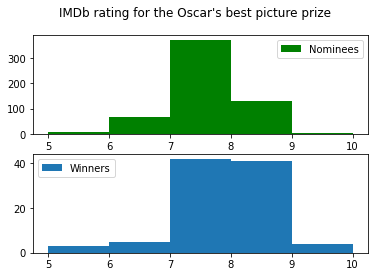

,id,status,movie_title,imdb_rating_imdb,runtime_mins,year_imdb,genres_imdb,release_date,directors,quarter,...,year_omdb,rated,genres_omdb,director,Writer,language,country,imdb_rating_omdb,imdbID,box_office
283,tt0068646,Oscar winner 1973,The Godfather,9.2,175,1972,"Crime, Drama",1972-03-14,Francis Ford Coppola,1,...,1972,R,"Crime, Drama",Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","English, Italian, Latin",United States,9.2,tt0068646,136381073.0
293,tt0071562,Oscar winner 1975,The Godfather Part II,9.0,202,1974,"Crime, Drama",1974-12-12,Francis Ford Coppola,4,...,1974,R,"Crime, Drama",Francis Ford Coppola,"Francis Ford Coppola, Mario Puzo","English, Italian, Spanish, Latin, Sicilian",United States,9.0,tt0071562,47834595.0
388,tt0108052,Oscar winner 1994,Schindler's List,9.0,195,1993,"Biography, Drama, History",1993-11-30,Steven Spielberg,4,...,1993,R,"Biography, Drama, History",Steven Spielberg,"Thomas Keneally, Steven Zaillian","English, Hebrew, German, Polish, Latin",United States,9.0,tt0108052,96898818.0
438,tt0167260,Oscar winner 2004,The Lord of the Rings: The Return of the King,9.0,201,2003,"Action, Adventure, Drama, Fantasy",2003-12-01,Peter Jackson,4,...,2003,PG-13,"Action, Adventure, Drama",Peter Jackson,"J.R.R. Tolkien, Fran Walsh, Philippa Boyens","English, Quenya, Old English, Sindarin","New Zealand, United States",9.0,tt0167260,378251207.0
393,tt0109830,Oscar winner 1995,Forrest Gump,8.8,142,1994,"Drama, Romance",1994-06-23,Robert Zemeckis,2,...,1994,PG-13,"Drama, Romance",Robert Zemeckis,"Winston Groom, Eric Roth",English,United States,8.8,tt0109830,330455270.0
298,tt0073486,Oscar winner 1976,One Flew Over the Cuckoo's Nest,8.7,133,1975,Drama,1975-11-19,Milos Forman,4,...,1975,18+,Drama,Milos Forman,"Lawrence Hauben, Bo Goldman, Ken Kesey",English,United States,8.7,tt0073486,108981275.0
378,tt0102926,Oscar winner 1992,The Silence of the Lambs,8.6,118,1991,"Crime, Drama, Thriller",1991-01-30,Jonathan Demme,1,...,1991,R,"Crime, Drama, Thriller",Jonathan Demme,"Thomas Harris, Ted Tally","English, Latin",United States,8.6,tt0102926,130742922.0
132,tt0034583,Oscar winner 1944,Casablanca,8.5,102,1942,"Drama, Romance, War",1942-11-26,Michael Curtiz,4,...,1942,PG,"Drama, Romance, War",Michael Curtiz,"Julius J. Epstein, Philip G. Epstein, Howard Koch","English, French, German, Italian",United States,8.5,tt0034583,4219709.0
557,tt6751668,Oscar winner 2020,Gisaengchung,8.5,132,2019,"Drama, Thriller",2019-05-21,Bong Joon Ho,2,...,2019,R,"Drama, Thriller",Bong Joon Ho,"Bong Joon Ho, Han Jin-won","Korean, English",South Korea,8.5,tt6751668,53369749.0
423,tt0172495,Oscar winner 2001,Gladiator,8.5,155,2000,"Action, Adventure, Drama",2000-05-01,Ridley Scott,2,...,2000,R,"Action, Adventure, Drama",Ridley Scott,"David Franzoni, John Logan, William Nicholson",English,"United States, United Kingdom, Malta, Morocco",8.5,tt0172495,187705427.0


In [ ]:
%matplotlib inline
bins=range(5,11,1)
winners = imdb_omdb[imdb_omdb['status'].notna()]
fig, ax = plt.subplots(2) 
ax[0].hist(imdb_omdb['imdb_rating_imdb'],bins=bins,color='g')
ax[1].hist(winners['imdb_rating_imdb'],bins=bins)
ax[0].legend(['Nominees'])
ax[1].legend(['Winners'])
plt.suptitle("IMDb rating for the Oscar's best picture prize")
plt.show()
winners = winners.sort_values('imdb_rating_imdb', ascending=False)
winners.head(10)